**Jack Dai**

Spring 2026

CS 252: Mathematical Data Analysis and Visualization

Project 2: Linear regression

#### Week 2: QR-based linear regression


In [3]:
import numpy as np
import matplotlib.pyplot as plt

import data
import linear_regression

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Task 5: A QR-based linear regression solver


This task focuses on the implementation of a least squares solver that relies on the QR decomposition of the A matrix.

1. Write algorithm to compute QR decomposition (`linear_regression::qr_decomposition`). **Run test code below.** Equation for R: $$R = Q^TA$$
2. Implement `linear_regression::linear_regression_qr` to use the QR decomposition to do the linear regression. Recall that the equation is $$Rc = Q^Ty$$ which can be solved without taking the inverse of $R$ through backsolving.


#### Test QR decomposition


In [4]:
iris_filename = 'data/iris.csv'
iris_data = data.Data(iris_filename)

A = iris_data.select_data(['sepal_length', 'petal_width'])
A1 = np.hstack([A, np.ones([len(A), 1])])

lin_reg_qr = linear_regression.LinearRegression(iris_data)
myQ, myR = lin_reg_qr.qr_decomposition(A1)

Q, R = np.linalg.qr(A1)

print(f'Your Q shape is {myQ.shape} and should be {Q.shape}')
print(f'Your R shape is {myR.shape} and should be {R.shape}')
print(f'1st few rows of your Q are\n{myQ[:3]} and should be\n{Q[:3]}')
print('NOTE: It is fine if your Q numbers match in absolute value\nbut 1 or more COLUMNS are negated.')
print(f'\nYour R is\n{myR} and should be\n{R}')
print('NOTE: It is fine if your R numbers match in absolute value\nbut 1 or more ROWS are negated.\n')

Your Q shape is (150, 3) and should be (150, 3)
Your R shape is (3, 3) and should be (3, 3)
1st few rows of your Q are
[[ 0.07056 -0.11765  0.00009]
 [ 0.0678  -0.11202  0.0339 ]
 [ 0.06503 -0.10638  0.06772]] and should be
[[-0.07056 -0.11765 -0.00009]
 [-0.0678  -0.11202 -0.0339 ]
 [-0.06503 -0.10638 -0.06772]]
NOTE: It is fine if your Q numbers match in absolute value
but 1 or more COLUMNS are negated.

Your R is
[[72.27621 15.60873 12.12709]
 [-0.       7.66143 -1.22542]
 [-0.      -0.       1.19668]] and should be
[[-72.27621 -15.60873 -12.12709]
 [  0.        7.66143  -1.22542]
 [  0.        0.       -1.19668]]
NOTE: It is fine if your R numbers match in absolute value
but 1 or more ROWS are negated.



#### Test linear regression via QR decomposition

If everything is working as expected, you should reproduce the same plot that you obtained for the SciPy and Normal Equations solvers.


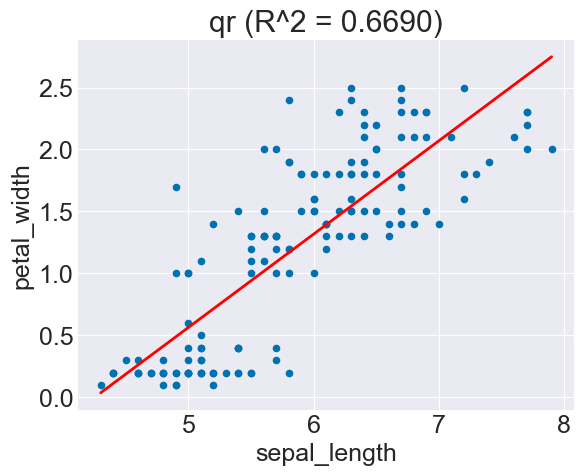

In [5]:
lin_reg_qr.linear_regression(['sepal_length'], 'petal_width', 'qr')
lin_reg_qr.scatter('sepal_length', 'petal_width', 'qr')
lin_reg_qr.show()

## Task 6: Benchmarking the least squares solvers on the wave dataset

You have added support for 3 least squares solver methods in `LinearRegression` â€” SciPy, Normal Equations, QR. Let's compare their stability on the wave dataset!

In the cell below, copy-and-paste your code that loads in the `wave_fit.csv`.


In [6]:
# YOUR CODE HERE
wave_fit_filename = 'data/wave_fit.csv'
wave_fit_data = data.Data(wave_fit_filename)
print(wave_fit_data)

-------------------------------
data/wave_fit.csv (150x2)
Headers:
  x	y
-------------------------------
Showing first 5/150 rows.
2.0858	-0.4942
4.6724	-5.85
2.4812	-3.3264
0.2579	4.5996
-0.9518	4.9771

-------------------------------


### 6a. Varying the model polynomial degree


In the cell below, create a single plot with 3 curves â€” the $R^2$ obtained on the wave dataset fit set when separate polynomial regressions are fit to the wave fit set with polynomial degrees `1`, `2`, `3`, `...` with each of the 3 least square solver methods.

- The x axis should show the model polynomial degree.
- The y axis should show the fit set $R^2$.
- Limit the y axis range of the plotted $R^2$ values to span the valid range of values (_you should to set this explicitly and not assume your computed $R^2$ values will always be in the valid range_).
- The legend should indicate which solver corresponds to which colored curve.

Create 3 separate versions of the plot below (_have the below cell show all 3_):

1. the polynomial degree goes to 20.
2. the polynomial degree goes to 25.
3. the polynomial degree goes to 100.


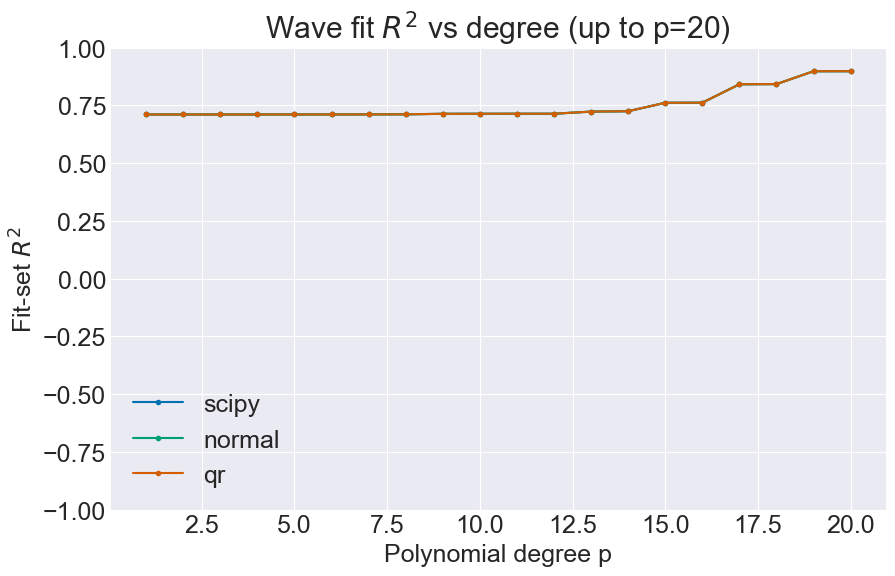

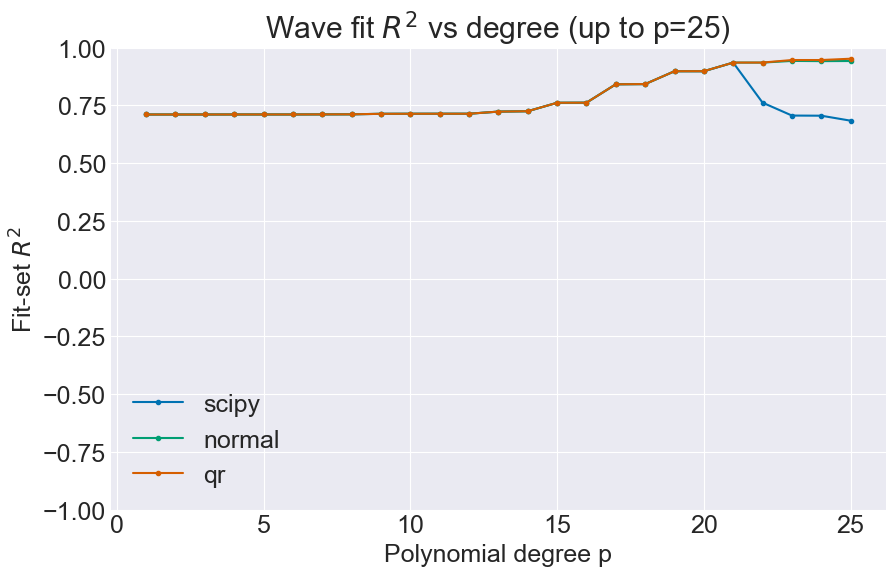

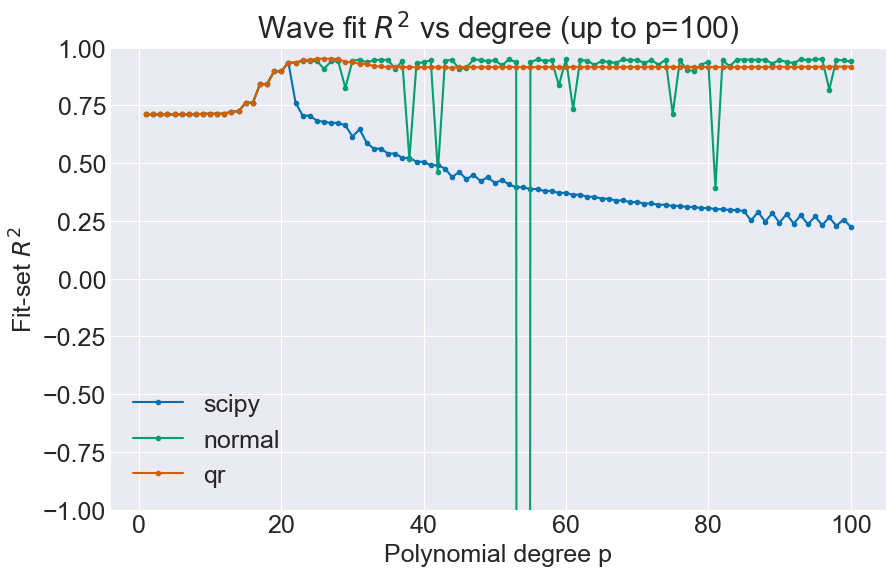

In [7]:
# YOUR CODE HERE
methods = ['scipy', 'normal', 'qr']
max_degrees = [20, 25, 100]
benchmark_results = {}
benchmark_degrees = {}

for max_degree in max_degrees:
    degrees = np.arange(1, max_degree + 1)
    benchmark_degrees[max_degree] = degrees
    benchmark_results[max_degree] = {method: [] for method in methods}

    for p in degrees:
        for method in methods:
            lr = linear_regression.LinearRegression(wave_fit_data)
            try:
                lr.poly_regression('x', 'y', p, method=method)
                benchmark_results[max_degree][method].append(lr.R2)
            except Exception:
                benchmark_results[max_degree][method].append(np.nan)

    plt.figure(figsize=(10, 6))
    for method in methods:
        plt.plot(degrees, benchmark_results[max_degree][method], marker='o', markersize=3, label=method)
    plt.xlabel('Polynomial degree p')
    plt.ylabel('Fit-set $R^2$')
    plt.ylim(-1, 1)
    plt.title(f'Wave fit $R^2$ vs degree (up to p={max_degree})')
    plt.legend()
    plt.show()

### 6b. Visualizing differences among solvers when fitting high degree polynomials

Create 3 plots that show the model fit/predictions on the fit set when the polynomial degree is 3 larger than the point at which the solvers start to show departures in their $R^2$ values.

_It should be helpful/quick to copy-paste and modify your plotting code from the polynomial regression notebook._


First visible solver departure near p=22; plotting p=25.


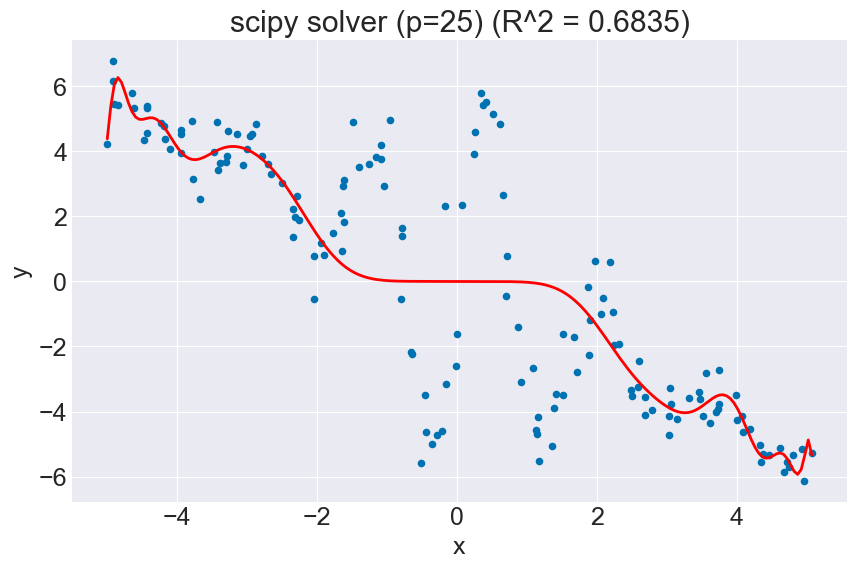

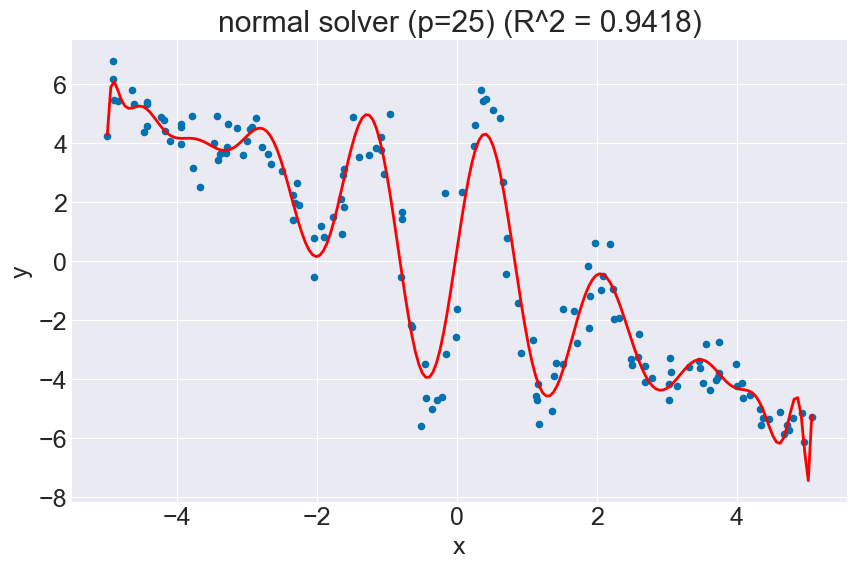

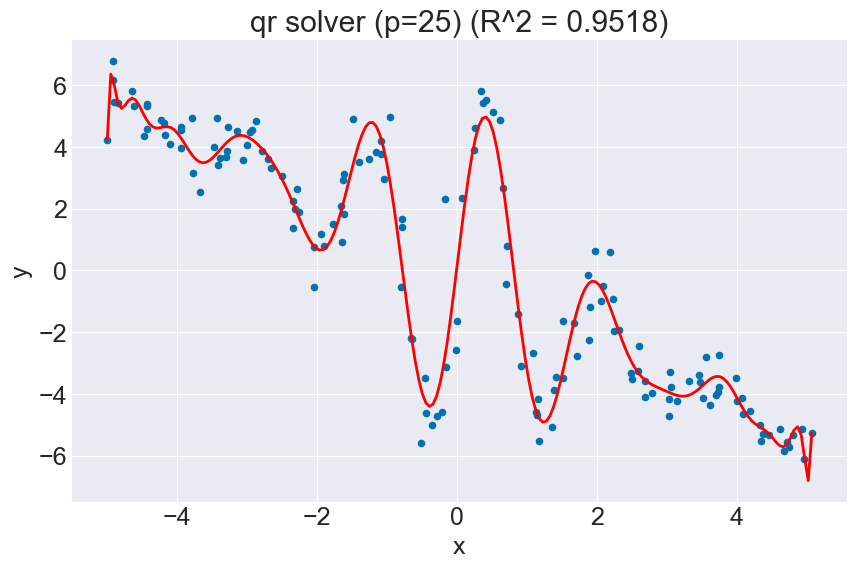

In [8]:
# YOUR CODE HERE
departure_p = None
degrees = benchmark_degrees[100]
tol = 1e-3

for i, p in enumerate(degrees):
    vals = np.array([benchmark_results[100][method][i] for method in methods], dtype=float)
    if np.any(~np.isfinite(vals)) or (np.nanmax(vals) - np.nanmin(vals) > tol):
        departure_p = p
        break

if departure_p is None:
    departure_p = 100

plot_p = min(departure_p + 3, 100)
print(f'First visible solver departure near p={departure_p}; plotting p={plot_p}.')

for method in methods:
    plt.figure(figsize=(10, 6))
    lr = linear_regression.LinearRegression(wave_fit_data)
    try:
        lr.poly_regression('x', 'y', plot_p, method=method)
        lr.scatter('x', 'y', f'{method} solver (p={plot_p})')
    except Exception as e:
        x = wave_fit_data.select_data(['x']).ravel()
        y = wave_fit_data.select_data(['y']).ravel()
        plt.scatter(x, y, s=20)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'{method} solver failed at p={plot_p}')
        plt.text(0.05, 0.95, str(e), transform=plt.gca().transAxes, va='top')
    plt.show()

### 6c. Questions

**Question 8:** Which solver most closely exhibits results that match our expectations for high $p$ values.

**Question 9:** Based on your analysis above, what is your overall ranking of the best solvers, from most to least stable? Provide specific evidence from your results to support your ordering.

**Question 10:** Based on your plots in the previous subtask (with fixed $p$, one plot per solver), which among the that did not perform the best demonstrated the most resilience/graceful failure under the challenging computational conditions?

**Question 11:** What surprised you about the results that you obtained?


**Answer 8:**


The QR solver most closely matches expectations for high $p$ values because its $R^2$ remains high and its fitted curves stay reasonable even when the polynomial degree becomes large.


**Answer 9:**


Overall stability ranking: QR, then Normal Equations, then SciPy. QR stayed the most consistent at high degrees, Normal Equations followed QR for a while but developed instability spikes at larger $p$, and SciPy showed the earliest sustained degradation once the degree became high.


**Answer 10:**


Among the non-best methods, Normal Equations showed the most graceful failure because it remained close to QR longer, whereas SciPy drifted away earlier and more steadily as $p$ increased.


**Answer 11:**


What surprised me most was that Normal Equations stayed competitive with QR up to fairly high polynomial degrees before becoming unstable; I expected it to break down much sooner.


## Task 7: Compare performance of the linear regression methods on brain data

The brain dataset contains electrical [EEG](https://en.wikipedia.org/wiki/Electroencephalography) measurements from different locations on the scalp of the human head.

### 7a. Run linear regressions on brain data with different solvers

1. In the cell below, load in the brain network `brain.csv` dataset.
2. Create `Data` and `LinearRegression` objects.
3. Load in the list of variable names in the brain dataset (62)
4. Do multiple linear regressions, separately for each of the 3 linear regression methods that you have implemented: Set all brain data variables except for the last one as the independent variables, the last variable is the dependent variable.
5. Compute and print the mean squared error (MSE) in the predictions made by each linear regression model and the actual y values.


In [9]:
# YOUR CODE HERE
brain_filename = 'data/brain.csv'
brain_data = data.Data(brain_filename)
brain_headers = brain_data.get_headers()
brain_ind_vars = brain_headers[:-1]
brain_dep_var = brain_headers[-1]

print(brain_data)
print(f'Number of variables: {len(brain_headers)}')
print(f'Dependent variable: {brain_dep_var}')

-------------------------------
data/brain.csv (60x62)
Headers:
  1	1.1	2	2.1	3	3.1	4	4.1	5	5.1	6	6.1	6.2	6.3	7	7.1	7.2	7.3	7.4	7.5	8	8.1	8.2	8.3	8.4	8.5	9	9.1	10	10.1	11	11.1	12	12.1	12.2	12.3	12.4	13	13.1	13.2	13.3	13.4	13.5	14	14.1	15	15.1	16	16.1	16.2	16.3	16.4	16.5	16.6	16.7	17	17.1	17.2	17.3	17.4	17.5	17.6
-------------------------------
Showing first 5/60 rows.
56.05574417114258	92.03103637695312	3.391575574874878	38.65968322753906	26.203819274902344	-49.71556854248047	47.4610366821289	26.746612548828125	-35.898860931396484	-1.8891807794570925	5.898688316345215	-43.69232177734375	-47.66426467895508	12.2841215133667	1.5665380954742432	-13.042585372924805	-1.8552596569061282	-39.80590057373047	-30.831512451171875	-61.13700866699219	-25.82785606384277	39.02416229248047	-29.97164535522461	-6.1323723793029785	-56.75698852539063	0.2101360559463501	-33.01984405517578	2.9784927368164062	-8.327313423156737	15.077152252197266	-10.35627269744873	18.01881599426269	-63.29214477539063	-75.995

In [10]:
# YOUR CODE HERE
brain_lr_scipy = linear_regression.LinearRegression(brain_data)
brain_lr_scipy.linear_regression(brain_ind_vars, brain_dep_var, method='scipy')
print(f'SciPy MSE: {brain_lr_scipy.mse}')

SciPy MSE: 6.289393740329217e-26


In [11]:
# YOUR CODE HERE
brain_lr_normal = linear_regression.LinearRegression(brain_data)
brain_lr_normal.linear_regression(brain_ind_vars, brain_dep_var, method='normal')
print(f'Normal-equations MSE: {brain_lr_normal.mse}')

Normal-equations MSE: 1.7677166247649168e-23


In [12]:
# YOUR CODE HERE
brain_lr_qr = linear_regression.LinearRegression(brain_data)
brain_lr_qr.linear_regression(brain_ind_vars, brain_dep_var, method='qr')
print(f'QR MSE: {brain_lr_qr.mse}')

QR MSE: 4.287667000457194e-22


### 7b. Questions

**Question 12:** What are the mean squared errors for each of the regression methods on the brain data? Which method(s) do best and which do the worst **and why**?


**Answer 12:**


The mean squared errors on the brain data were approximately: SciPy $6.29 \times 10^{-26}$, Normal Equations $1.77 \times 10^{-23}$, and QR $4.29 \times 10^{-22}$. SciPy did best and QR did worst here, although all three errors were extremely small, so in practice they all performed very well. The likely reason is that this regression problem was numerically well-behaved enough that all methods could solve it accurately, with only tiny floating-point differences separating them.
